In [3]:
import polars as pl
pl.Config.set_tbl_width_chars(500)      # Tăng chiều rộng table
pl.Config.set_tbl_cols(20)              # Hiển thị nhiều cột
pl.Config.set_tbl_rows(100)             # Hiển thị nhiều rows
pl.Config.set_fmt_str_lengths(1000)     # Độ dài string max (full S3 path)

polars.config.Config

📖 Reading .rec file...
  Header found: total=42473116, label_width=44531580


Reading records: 100%|██████████████████████████████████████████████████████████████████████████| 42473115/42473115 [08:14<00:00, 85870.55it/s]


  Total data records : 42,473,115
  Total identities   : 2,058,464

📊 Image Count per Identity:
  Total identities : 2,058,464
  Total images     : 42,473,115
  Min              : 2
  Max              : 2621
  Mean             : 20.63
  Median           : 11.0
  Std              : 28.26

📊 Histogram Counts:
         3-5:    469,930
        6-10:    524,790
       11-20:    462,062
       21-40:    358,575
       41-70:    131,777
      71-100:     56,429
     101-150:     38,047
     151-200:     13,389
     201-500:      3,311
        500+:        154


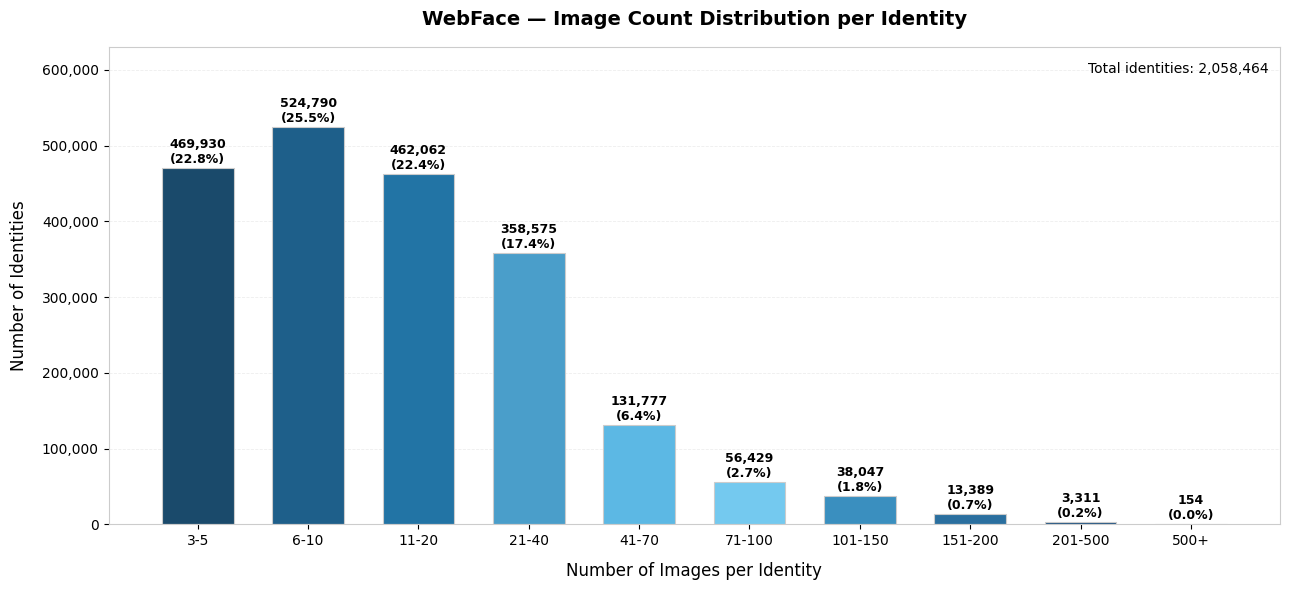


✅ Saved: webface_img_count_distribution.png


In [5]:
import mxnet as mx
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import tqdm
from tqdm import tqdm
# --- CONFIG ---
REC_PATH = "output_parquet/data_process/face_embedding_normalize/WebFace42M/train.rec"
IDX_PATH = "output_parquet/data_process/face_embedding_normalize/WebFace42M/train.idx"
print("📖 Reading .rec file...")
record = mx.recordio.MXIndexedRecordIO(IDX_PATH, REC_PATH, "r")

# --- Xác định valid indices theo đúng logic header ---
s = record.read_idx(0)
header0, _ = mx.recordio.unpack(s)

if header0.flag > 0:
    print(f"  Header found: total={int(header0.label[0])}, label_width={int(header0.label[1])}")
    imgidx = np.array(range(1, int(header0.label[0])))
else:
    print("  No header record, using all keys")
    imgidx = np.array(list(record.keys))

# --- Đếm ảnh per identity ---
id_counter = Counter()

for key in tqdm(imgidx, desc="Reading records"):
    item = record.read_idx(key)
    header, _ = mx.recordio.unpack(item)
    person_id = int(header.label[0]) if hasattr(header.label, '__len__') else int(header.label)
    id_counter[person_id] += 1

print(f"  Total data records : {len(imgidx):,}")
print(f"  Total identities   : {len(id_counter):,}")

# --- STEP 2: Polars DataFrame ---
df_count = pl.DataFrame({
    "person_id": list(id_counter.keys()),
    "img_count": list(id_counter.values()),
})

counts = df_count["img_count"]

# --- STEP 3: Stats ---
print("\n📊 Image Count per Identity:")
print(f"  Total identities : {len(counts):,}")
print(f"  Total images     : {counts.sum():,}")
print(f"  Min              : {counts.min()}")
print(f"  Max              : {counts.max()}")
print(f"  Mean             : {counts.mean():.2f}")
print(f"  Median           : {counts.median():.1f}")
print(f"  Std              : {counts.std():.2f}")

# --- STEP 4: Binning ---
labels = ["3-5", "6-10", "11-20", "21-40", "41-70", "71-100", "101-150", "151-200", "201-500", "500+"]

df_hist = df_count.with_columns(
    pl.when(pl.col("img_count") <= 5).then(pl.lit("3-5"))
    .when(pl.col("img_count") <= 10).then(pl.lit("6-10"))
    .when(pl.col("img_count") <= 20).then(pl.lit("11-20"))
    .when(pl.col("img_count") <= 40).then(pl.lit("21-40"))
    .when(pl.col("img_count") <= 70).then(pl.lit("41-70"))
    .when(pl.col("img_count") <= 100).then(pl.lit("71-100"))
    .when(pl.col("img_count") <= 150).then(pl.lit("101-150"))
    .when(pl.col("img_count") <= 200).then(pl.lit("151-200"))
    .when(pl.col("img_count") <= 500).then(pl.lit("201-500"))
    .otherwise(pl.lit("500+"))
    .alias("bin")
).with_columns(
    pl.col("bin").cast(pl.Enum(labels))
)

bin_counts = (
    df_hist.group_by("bin")
    .agg(pl.len().alias("count"))
    .sort("bin")
)

print("\n📊 Histogram Counts:")
for row in bin_counts.iter_rows(named=True):
    print(f"  {row['bin']:>10}: {row['count']:>10,}")

# --- STEP 5: Plot ---
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bin_labels = bin_counts["bin"].to_list()
bin_vals   = bin_counts["count"].to_list()
total_ids  = sum(bin_vals)

colors = [
    "#1a4a6b", "#1e5f8a", "#2274a5", "#4a9eca",
    "#5cb8e4", "#74c9ef", "#3a8fbf", "#2a6f9f",
    "#1a4f7f", "#0d3560"
]

bars = ax.bar(bin_labels, bin_vals, color=colors, edgecolor="#cccccc", linewidth=0.8, width=0.65)

for bar, val in zip(bars, bin_vals):
    pct = val / total_ids * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(bin_vals) * 0.005,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom",
        color="black", fontsize=9, fontweight="bold"
    )

ax.set_xlabel("Number of Images per Identity", color="black", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Identities", color="black", fontsize=12, labelpad=10)
ax.set_title("WebFace — Image Count Distribution per Identity", color="black", fontsize=14, fontweight="bold", pad=16)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.tick_params(colors="black", labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")

ax.set_ylim(0, max(bin_vals) * 1.2)
ax.yaxis.grid(True, color="#eeeeee", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

ax.text(0.99, 0.97, f"Total identities: {total_ids:,}",
        transform=ax.transAxes, ha="right", va="top",
        color="black", fontsize=10)

plt.tight_layout()
plt.savefig("webface_img_count_distribution.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("\n✅ Saved: webface_img_count_distribution.png")

In [82]:
import polars as pl

df = pl.read_parquet("/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/template_clean/template_before_merge_webface/centers_v2.parquet")
print(len(df))
print(len(df['person_id'].unique()))


counts = df["person_id"].value_counts(sort=True)
duplicate_ids = counts.filter(pl.col("count") > 1)
print(len(duplicate_ids))

# df = df.unique(subset=["person_id"], keep="first")
# print(len(df))
# print(len(df['person_id'].unique()))

1436761
1436761
0


In [77]:
print(duplicate_ids[:5])

shape: (5, 2)
┌───────────┬───────┐
│ person_id ┆ count │
│ ---       ┆ ---   │
│ i64       ┆ u32   │
╞═══════════╪═══════╡
│ 3011284   ┆ 2     │
│ 4820320   ┆ 2     │
│ 3036090   ┆ 2     │
│ 3036833   ┆ 2     │
│ 4457906   ┆ 2     │
└───────────┴───────┘


In [80]:
filtered = df.filter(pl.col('person_id') == 3011284)
print(filtered)

shape: (2, 3)
┌───────────┬───────────┬────────────────────────────────────┐
│ person_id ┆ img_count ┆ embedding_center                   │
│ ---       ┆ ---       ┆ ---                                │
│ i64       ┆ i64       ┆ list[f32]                          │
╞═══════════╪═══════════╪════════════════════════════════════╡
│ 3011284   ┆ 6         ┆ [-0.008131, -0.068178, … 0.069611] │
│ 3011284   ┆ 3         ┆ [-0.029513, -0.064761, … 0.096109] │
└───────────┴───────────┴────────────────────────────────────┘


In [ ]:
import polars as pl

df = pl.read_parquet("/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/template_clean/template_before_merge_webface/centers_v2.parquet")
print(len(df))
print(len(df['person_id'].unique()))
print(df.head(12))
print(df.tail(12))

In [52]:
df.head()

person_id,img_count,embedding_center
i64,i64,list[f32]
3000009,4,"[-0.039722, 0.03982, … 0.01796]"
3000010,3,"[0.01763, 0.034981, … -0.044842]"
3000012,39,"[-0.028759, -0.138986, … 0.042449]"
3000016,3,"[0.059509, 0.028416, … -0.065023]"
3000020,4,"[-0.059889, -0.016539, … -0.00272]"


In [53]:
df.tail()

person_id,img_count,embedding_center
i64,i64,list[f32]
5826015,3,"[-0.003887, 0.000522, … 0.009037]"
5826016,3,"[0.063847, 0.047948, … -0.017492]"
5826017,3,"[-0.084442, 0.030761, … 0.011094]"
5826018,7,"[-0.011246, -0.00204, … 0.066019]"
5826020,6,"[0.010315, -0.013982, … 0.106341]"


In [112]:
df = pl.read_parquet("output_parquet/data_process/face_embedding_normalize/clean_data_merge/v1_ivf_real_only_new_id/*.parquet")
print(df.columns)
print(len(df))
print(len(df['person_id'].unique()))

['person_id', 'embedding_normalized', 'aligned_s3_path']
19035724
1068367


In [110]:
df = pl.read_parquet("output_parquet/data_process/face_embedding_normalize/clean_data_merge/v1_ivf_real_only_new_id_after_merge_webface/*.parquet")
print(df.columns)
print(len(df))
print(len(df['person_id'].unique()))

['person_id', 'embedding_normalized', 'aligned_s3_path']
19035724
1068367


In [113]:
df = pl.read_parquet("output_parquet/data_process/face_embedding_normalize/clean_data_merge/v1_ivf_real_only_new_id_after_merge_webface_public/*.parquet")
print(df.columns)
print(len(df))
print(len(df['person_id'].unique()))

['person_id', 'embedding_normalized', 'aligned_s3_path']
18153026
1049499


In [111]:
df.head()

person_id,embedding_normalized,aligned_s3_path
i64,list[f64],str
4420252,"[-0.061101, -0.023563, … -0.114178]","""cv/processed-datasets/aligned_face_112_112/person_1420000_1420999/person_1420252.tar/cv_crawled-datasets_face-google-search_data_0_00409.tar_004097429.jpg_face_0.jpg"""
4420252,"[-0.047863, 0.019469, … -0.123934]","""cv/processed-datasets/aligned_face_112_112/person_1420000_1420999/person_1420252.tar/cv_crawled-datasets_face-google-search_data_0_00409.tar_004097441.jpg_face_2.jpg"""
4420252,"[-0.045291, -0.028103, … -0.133399]","""cv/processed-datasets/aligned_face_112_112/person_1420000_1420999/person_1420252.tar/cv_crawled-datasets_face-google-search_data_0_00409.tar_004097438.jpg_face_0.jpg"""
4420252,"[-0.087403, -0.025247, … -0.054276]","""cv/processed-datasets/aligned_face_112_112/person_1420000_1420999/person_1420252.tar/cv_crawled-datasets_face-google-search_data_0_00409.tar_004097452.jpg_face_1.jpg"""
4420252,"[-0.05308, -0.064929, … -0.080306]","""cv/processed-datasets/aligned_face_112_112/person_1420000_1420999/person_1420252.tar/cv_crawled-datasets_face-google-search_data_0_00409.tar_004097450.jpg_face_0.jpg"""


In [99]:
df = pl.read_parquet("output_parquet/data_process/face_embedding_normalize/clean_data_merge/v1_ivf_real_only_new_id_after_merge_webface_public/*.parquet")
print(df.columns)
print(len(df))
print(len(df['person_id'].unique()))

['person_id', 'embedding_normalized', 'aligned_s3_path']
31486435
1417902


In [100]:
df.head()

person_id,embedding_normalized,aligned_s3_path
i64,list[f64],str
5608543,"[-0.026011, -0.06349, … 0.021447]","""cv/processed-datasets/aligned_face_112_112/person_2594000_2594999/person_2594205.tar/cv_crawled-datasets_face-google-search_data_1000_00635.tar_006355864.jpg_face_0.jpg"""
5608543,"[-0.048073, -0.017796, … 0.023957]","""cv/processed-datasets/aligned_face_112_112/person_2594000_2594999/person_2594205.tar/cv_crawled-datasets_face-google-search_data_1000_00635.tar_006355878.jpg_face_0.jpg"""
5608543,"[-0.029641, -0.029767, … 0.008122]","""cv/processed-datasets/aligned_face_112_112/person_2594000_2594999/person_2594205.tar/cv_crawled-datasets_face-google-search_data_1000_00635.tar_006355884.jpg_face_0.jpg"""
5608543,"[-0.025224, -0.012278, … -0.013474]","""cv/processed-datasets/aligned_face_112_112/person_2594000_2594999/person_2594205.tar/cv_crawled-datasets_face-google-search_data_1000_00635.tar_006355882.jpg_face_0.jpg"""
5608543,"[-0.039515, -0.011829, … 0.039845]","""cv/processed-datasets/aligned_face_112_112/person_2594000_2594999/person_2594205.tar/cv_crawled-datasets_face-google-search_data_1000_00635.tar_006355888.jpg_face_0.jpg"""


In [94]:
import polars as pl
df = pl.read_parquet("output_parquet/data_process/face_embedding_normalize/template_clean/template_after_merge_webface_public/cleaned_crawl_centers.parquet")
print(len(df))
print(len(df['person_id'].unique()))

1049523
1049508


In [105]:
import polars as pl
df = pl.read_parquet("output_parquet/data_process/face_embedding_normalize/template_clean/template_webface*/*.parquet")
print(len(df))
print(len(df['person_id'].unique()))
df.tail(2)

2058464
2058464


person_id,img_count,embedding_center
i64,i64,list[f32]
2058462,31,"[0.069115, -0.019748, … 0.036227]"
2058463,4,"[0.080062, 0.079711, … -0.031847]"


In [106]:
import polars as pl
df = pl.read_parquet("output_parquet/data_process/face_embedding_normalize/template_clean/template_public5m/centers.parquet")
print(len(df))
print(len(df['person_id'].unique()))
df.head(3)
df.tail(3)

558208
558208


person_id,img_count,embedding_center
i64,i64,list[f32]
2616670,5,"[-0.026062, 0.040343, … -0.054444]"
2616671,5,"[-0.005444, -0.019134, … -0.010596]"
2616672,5,"[-0.039029, -0.012158, … -0.00171]"


In [96]:
 df.head(20)

person_id,img_count,embedding_center
i64,i64,list[f32]
5546125,14,"[0.039837, 0.041435, … -0.012678]"
3324974,14,"[-0.064371, -0.007545, … 0.018419]"
3410833,18,"[-0.009891, -0.02757, … -0.047796]"
3496296,4,"[-0.046448, -0.033153, … 0.047105]"
3825569,8,"[-0.083624, 0.080755, … -0.018101]"
4392096,29,"[-0.038818, 0.020915, … 0.038525]"
4503384,8,"[0.042333, 0.050098, … 0.035996]"
5123523,4,"[-0.067963, -0.08997, … 0.006929]"
5692015,3,"[0.006058, -0.038385, … 0.007074]"


In [7]:
len(df_faces)

106787445

In [9]:
df_faces.write_parquet("output_parquet/data_process/has_face/all_data.parquet")

In [10]:
LIMIT = 3

total_faces_capped = df_faces.select(
    pl.col("num_faces").clip(upper_bound=LIMIT).sum()
).item()

print(f"Total faces (max {LIMIT}/image): {total_faces_capped:,}")

Total faces (max 3/image): 181,399,823


In [15]:
LIMIT = 199

# Dùng hàm clip để giới hạn: nếu > 3 thì lấy 3, nếu < 3 thì giữ nguyên
total_faces_capped = df_faces.select(
    pl.col("num_faces").clip(upper_bound=LIMIT).sum()
).item()

print(f"Total faces (max {LIMIT}/image): {total_faces_capped:,}")

Total faces (max 199/image): 336,651,394


In [3]:
import polars as pl
import numpy as np
import ast
import time
import os
from multiprocessing import Pool
from tqdm.auto import tqdm

INPUT_PARQUET = "output_parquet/data_process/has_face/all_data.parquet"
OUTPUT_PARQUET = "output_parquet/data_process/top_N_faces/top5_faces_exploded.parquet"
OUTPUT_MAPPING = "output_parquet/data_process/person_id_mapping.csv"
MIN_SIZE_PX = 20
MIN_AREA = MIN_SIZE_PX * MIN_SIZE_PX
TOP_K = 5
NUM_WORKERS = 4
CHUNKS_PER_WORKER = 50
TEST_RATIO=1000
TEST_MODE=False

def process_chunk(data_chunk):
    results = []
    for row in data_chunk:
        s3_path, name, bboxs_str, lms_str = row
        try:
            bboxes = ast.literal_eval(bboxs_str)
            landmarks = ast.literal_eval(lms_str)
            
            if not bboxes: continue
                
            valid_faces = []
            for i, (box, lm) in enumerate(zip(bboxes, landmarks)):
                w = box[2] - box[0]
                h = box[3] - box[1]
                area = w * h
                
                if area < MIN_AREA: continue
                
                valid_faces.append({'bbox': box, 'landmark': lm, 'area': area})
            
            if not valid_faces: continue

            valid_faces.sort(key=lambda x: x['area'], reverse=True)
            top_faces = valid_faces[:TOP_K]
            for idx, face in enumerate(top_faces):
                results.append((s3_path, name, idx, face['bbox'], face['landmark']))
                
        except Exception:
            continue
    return results

if __name__ == "__main__":
    os.makedirs(os.path.dirname(OUTPUT_PARQUET), exist_ok=True)
    
    print(f"[INIT] Reading Polars DataFrame from {INPUT_PARQUET}...")
    t0 = time.time()
    
    df_raw = pl.read_parquet(INPUT_PARQUET)
    print(f"[INFO] Loaded {df_raw.height} rows. Time: {time.time()-t0:.2f}s")

    total_rows = df_raw.height
    test_size = total_rows // TEST_RATIO
    if test_size==0:
        test_size = 10
    if TEST_MODE == True:
        df_raw = df_raw.head(test_size)

    print("[INFO] Converting to list for multiprocessing...")
    data_list = df_raw.select(['s3_path', 'name', 'bboxs', 'landmarks']).rows()
    
    total_target_chunks = NUM_WORKERS * CHUNKS_PER_WORKER
    chunk_size = len(data_list) // total_target_chunks + 1
    chunks = [data_list[i:i + chunk_size] for i in range(0, len(data_list), chunk_size)]
    total_chunks = len(chunks)
    
    print(f"[RUN] Starting processing {total_chunks} chunks with {NUM_WORKERS} workers...")
    
    dfs = []
    schema = ['s3_path', 'name', 'face_index', 'bbox', 'landmark']
    t_process = time.time()
    
    with Pool(processes=NUM_WORKERS) as pool:
        iterator = pool.imap(process_chunk, chunks)
        
        for res in tqdm(iterator, total=total_chunks, desc="Processing", unit="chunk"):
            if res:
                _df = pl.DataFrame(res, schema=schema, orient='row')
                dfs.append(_df)
            
    print(f"[INFO] Concatenating {len(dfs)} DataFrames...")
    df_faces = pl.concat(dfs)
    print(f"[DONE] Processing finished. Total faces: {df_faces.height}. Time: {time.time()-t_process:.2f}s")
    
    print("[INFO] Encoding Person IDs...")
    unique_names = df_faces['name'].unique().sort()
    
    df_mapping = pl.DataFrame({
        "person_id": range(len(unique_names)),
        "name": unique_names
    })

    df_mapping = df_mapping.with_columns(pl.col("person_id").cast(pl.Int32))
    

    df_final = df_faces.join(df_mapping, on="name", how="left")
    df_final = df_final.select(['person_id', 'name', 's3_path', 'face_index', 'bbox', 'landmark'])
    
    print(f"[SAVE] Saving mapping to {OUTPUT_MAPPING}...")
    df_mapping.write_csv(OUTPUT_MAPPING)
    
    print(f"[SAVE] Saving processed data to {OUTPUT_PARQUET}...")
    df_final.write_parquet(OUTPUT_PARQUET)
    
    print("-" * 40)
    print(f"COMPLETED in {time.time() - t0:.2f}s")
    print(f"Original Images: {len(data_list)}")
    print(f"Total Faces Kept: {df_final.height}")
    print(f"Unique Persons: {df_mapping.height}")
    print("-" * 40)

[INIT] Reading Polars DataFrame from output_parquet/data_process/has_face/all_data.parquet...
[INFO] Loaded 106787445 rows. Time: 15.73s
[INFO] Converting to list for multiprocessing...
[RUN] Starting processing 200 chunks with 4 workers...


Processing:   0%|          | 0/200 [00:03<?, ?chunk/s]

[INFO] Concatenating 200 DataFrames...
[DONE] Processing finished. Total faces: 197323984. Time: 17573.43s
[INFO] Encoding Person IDs...
[SAVE] Saving mapping to output_parquet/data_process/person_id_mapping.csv...
[SAVE] Saving processed data to output_parquet/data_process/top_N_faces/top5_faces_exploded.parquet...
----------------------------------------
COMPLETED in 19083.91s
Original Images: 106787445
Total Faces Kept: 197323984
Unique Persons: 2826021
----------------------------------------


In [7]:
import os
import glob

def count_txt(folder_path):
    """Đếm file .txt trong folder (không recursive)"""
    count = len([f for f in os.listdir(folder_path) if f.endswith('.txt')])
    print(f"Số file .txt: {count}")
    return count

# Sử dụng
count_txt('/workspace/FaceNist/raw_data_processing/output_parquet/data_process/checkpoints')  # Thay path

Số file .txt: 2


2

In [14]:
import polars as pl
import os
import glob

# --- CẤU HÌNH ---
PATH_BEFORE = "/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/face-embedding-normalize/face-embedding-normalize/**/*.parquet" # Dùng glob pattern để scan đệ quy
PATH_AFTER = "/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/dbscan_results/dbscan_v1/*.parquet" 

def get_stats(name, path_pattern):
    print(f"--- Analyzing {name} ({path_pattern}) ---")
    
    # 1. Lazy Scan (Chỉ đọc metadata, chưa load dữ liệu)
    # Lưu ý: Chỉ cần cột person_id để count
    q = pl.scan_parquet(path_pattern)


    # 2. Group by & Count (Vẫn là Lazy Plan)
    # Tính số ảnh cho mỗi ID
    q_counts = q.group_by("person_id").agg(pl.len().alias("img_count"))
    
    # 3. Collect (Thực thi và trả về DataFrame chứa [person_id, img_count])
    # Với 3 triệu ID, bảng này rất nhẹ (~20-50MB RAM)
    df_counts = q_counts.collect()
    
    if df_counts.height == 0:
        print("No data found.")
        return None

    # 4. Tính toán thống kê tổng quan
    total_faces = df_counts["img_count"].sum()
    total_ids = df_counts.height
    avg_faces = df_counts["img_count"].mean()
    min_faces = df_counts["img_count"].min()
    max_faces = df_counts["img_count"].max()
    
    # 5. Tính Histogram (Phân loại theo bin)
    # Logic: Tạo cột 'bin' dựa trên điều kiện
    bins = df_counts.with_columns(
        pl.when(pl.col("img_count") == 2).then(pl.lit("02"))
          .when(pl.col("img_count").is_between(3, 5)).then(pl.lit("03-05"))
          .when(pl.col("img_count").is_between(6, 10)).then(pl.lit("06-10"))
          .when(pl.col("img_count").is_between(11, 20)).then(pl.lit("11-20"))
          .when(pl.col("img_count").is_between(21, 50)).then(pl.lit("21-50"))
          .when(pl.col("img_count").is_between(51, 100)).then(pl.lit("51-100"))
          .when(pl.col("img_count").is_between(101, 200)).then(pl.lit("101-200"))
          .when(pl.col("img_count") > 200).then(pl.lit("200+"))
          .otherwise(pl.lit("01_or_Error")) # Dành cho trường hợp < 2 (nếu có)
          .alias("bin_label")
    ).group_by("bin_label").agg(pl.len().alias("count")).sort("bin_label")
    
    return {
        "total_faces": total_faces,
        "total_ids": total_ids,
        "avg": avg_faces,
        "min": min_faces,
        "max": max_faces,
        "bins": bins
    }

def print_comparison(stats_before, stats_after):
    print("\n" + "="*60)
    print(f"{'METRIC':<20} | {'BEFORE (Raw)':<20} | {'AFTER (Cleaned)':<20}")
    print("-" * 60)
    
    # Check if data exists
    b_faces = stats_before['total_faces'] if stats_before else 0
    a_faces = stats_after['total_faces'] if stats_after else 0
    b_ids = stats_before['total_ids'] if stats_before else 0
    a_ids = stats_after['total_ids'] if stats_after else 0
    
    # Format numbers
    print(f"{'Total Faces':<20} | {b_faces:,.0f}<20 | {a_faces:,.0f}")
    print(f"{'Total IDs':<20} | {b_ids:,.0f}<20 | {a_ids:,.0f}")
    
    if b_ids > 0 and a_ids > 0:
        retention_face = (a_faces / b_faces) * 100
        retention_id = (a_ids / b_ids) * 100
        print(f"{'Retention (%)':<20} | {'100%':<20} | F:{retention_face:.1f}% / ID:{retention_id:.1f}%")

    print(f"{'Avg Faces/ID':<20} | {stats_before['avg']:<20.2f} | {stats_after['avg']:<.2f}")
    print(f"{'Min Faces/ID':<20} | {stats_before['min']:<20} | {stats_after['min']}")
    print(f"{'Max Faces/ID':<20} | {stats_before['max']:<20} | {stats_after['max']}")
    
    print("\n--- DISTRIBUTION (Histogram) ---")
    print("-" * 50)
    
    # Merge 2 bảng bin để print
    if stats_before and stats_after:
        df_b = stats_before['bins'].rename({"count": "count_before"})
        df_a = stats_after['bins'].rename({"count": "count_after"})
        
        # # Join outer để lấy đủ các bin
        # df_merge = df_b.join(df_a, on="bin_label", how="full").fill_null(0).sort("bin_label")
        print(f"{'BIN RANGE':<15} | {'BEFORE (Count)':<15}")
        for row in df_b.iter_rows(named=True):
            print(f"{row['bin_label']:<15} | {row['count_before']:<15,.0f}")
        print("-" * 60)
        print(f"{'BIN RANGE':<15} | {'AFTER (Count)':<15}")
        for row in df_a.iter_rows(named=True):
            print(f"{row['bin_label']:<15} | {row['count_after']:<15,.0f}")

def main():
    stats_before = get_stats("BEFORE", PATH_BEFORE)
    print("Done scanning BEFORE.")
    
    stats_after = get_stats("AFTER", PATH_AFTER)
    print("Done scanning AFTER.")
    
    print_comparison(stats_before, stats_after)

if __name__ == "__main__":
    main()

--- Analyzing BEFORE (/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/face-embedding-normalize/face-embedding-normalize/**/*.parquet) ---
Done scanning BEFORE.
--- Analyzing AFTER (/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/dbscan_results/dbscan_v1/*.parquet) ---
Done scanning AFTER.

METRIC               | BEFORE (Raw)         | AFTER (Cleaned)     
------------------------------------------------------------
Total Faces          | 197,001,774<20 | 33,826,262
Total IDs            | 2,818,782<20 | 1,734,439
Retention (%)        | 100%                 | F:17.2% / ID:61.5%
Avg Faces/ID         | 69.89                | 19.50
Min Faces/ID         | 1                    | 3
Max Faces/ID         | 1947                 | 788

--- DISTRIBUTION (Histogram) ---
--------------------------------------------------
BIN RANGE       | BEFORE (Count) 
01_or_Error     | 25,375         
02              | 27,650

In [15]:

import polars as pl
import os
import glob

# --- CẤU HÌNH ---
PATH_BEFORE = "/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/face-embedding-normalize/face-embedding-normalize/**/*.parquet" # Dùng glob pattern để scan đệ quy
PATH_AFTER = "/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/dbscan_results/dbscan_v2/*.parquet" 

def get_stats(name, path_pattern):
    print(f"--- Analyzing {name} ({path_pattern}) ---")
    
    # 1. Lazy Scan (Chỉ đọc metadata, chưa load dữ liệu)
    # Lưu ý: Chỉ cần cột person_id để count
    q = pl.scan_parquet(path_pattern)


    # 2. Group by & Count (Vẫn là Lazy Plan)
    # Tính số ảnh cho mỗi ID
    q_counts = q.group_by("person_id").agg(pl.len().alias("img_count"))
    
    # 3. Collect (Thực thi và trả về DataFrame chứa [person_id, img_count])
    # Với 3 triệu ID, bảng này rất nhẹ (~20-50MB RAM)
    df_counts = q_counts.collect()
    
    if df_counts.height == 0:
        print("No data found.")
        return None

    # 4. Tính toán thống kê tổng quan
    total_faces = df_counts["img_count"].sum()
    total_ids = df_counts.height
    avg_faces = df_counts["img_count"].mean()
    min_faces = df_counts["img_count"].min()
    max_faces = df_counts["img_count"].max()
    
    # 5. Tính Histogram (Phân loại theo bin)
    # Logic: Tạo cột 'bin' dựa trên điều kiện
    bins = df_counts.with_columns(
        pl.when(pl.col("img_count") == 2).then(pl.lit("02"))
          .when(pl.col("img_count").is_between(3, 5)).then(pl.lit("03-05"))
          .when(pl.col("img_count").is_between(6, 10)).then(pl.lit("06-10"))
          .when(pl.col("img_count").is_between(11, 20)).then(pl.lit("11-20"))
          .when(pl.col("img_count").is_between(21, 50)).then(pl.lit("21-50"))
          .when(pl.col("img_count").is_between(51, 100)).then(pl.lit("51-100"))
          .when(pl.col("img_count").is_between(101, 200)).then(pl.lit("101-200"))
          .when(pl.col("img_count") > 200).then(pl.lit("200+"))
          .otherwise(pl.lit("01_or_Error")) # Dành cho trường hợp < 2 (nếu có)
          .alias("bin_label")
    ).group_by("bin_label").agg(pl.len().alias("count")).sort("bin_label")
    
    return {
        "total_faces": total_faces,
        "total_ids": total_ids,
        "avg": avg_faces,
        "min": min_faces,
        "max": max_faces,
        "bins": bins
    }

def print_comparison(stats_before, stats_after):
    print("\n" + "="*60)
    print(f"{'METRIC':<20} | {'BEFORE (Raw)':<20} | {'AFTER (Cleaned)':<20}")
    print("-" * 60)
    
    # Check if data exists
    b_faces = stats_before['total_faces'] if stats_before else 0
    a_faces = stats_after['total_faces'] if stats_after else 0
    b_ids = stats_before['total_ids'] if stats_before else 0
    a_ids = stats_after['total_ids'] if stats_after else 0
    
    # Format numbers
    print(f"{'Total Faces':<20} | {b_faces:,.0f}<20 | {a_faces:,.0f}")
    print(f"{'Total IDs':<20} | {b_ids:,.0f}<20 | {a_ids:,.0f}")
    
    if b_ids > 0 and a_ids > 0:
        retention_face = (a_faces / b_faces) * 100
        retention_id = (a_ids / b_ids) * 100
        print(f"{'Retention (%)':<20} | {'100%':<20} | F:{retention_face:.1f}% / ID:{retention_id:.1f}%")

    print(f"{'Avg Faces/ID':<20} | {stats_before['avg']:<20.2f} | {stats_after['avg']:<.2f}")
    print(f"{'Min Faces/ID':<20} | {stats_before['min']:<20} | {stats_after['min']}")
    print(f"{'Max Faces/ID':<20} | {stats_before['max']:<20} | {stats_after['max']}")
    
    print("\n--- DISTRIBUTION (Histogram) ---")
    print("-" * 50)
    
    # Merge 2 bảng bin để print
    if stats_before and stats_after:
        df_b = stats_before['bins'].rename({"count": "count_before"})
        df_a = stats_after['bins'].rename({"count": "count_after"})
        
        # # Join outer để lấy đủ các bin
        # df_merge = df_b.join(df_a, on="bin_label", how="full").fill_null(0).sort("bin_label")
        print(f"{'BIN RANGE':<15} | {'BEFORE (Count)':<15}")
        for row in df_b.iter_rows(named=True):
            print(f"{row['bin_label']:<15} | {row['count_before']:<15,.0f}")
        print("-" * 60)
        print(f"{'BIN RANGE':<15} | {'AFTER (Count)':<15}")
        for row in df_a.iter_rows(named=True):
            print(f"{row['bin_label']:<15} | {row['count_after']:<15,.0f}")

def main():
    stats_before = get_stats("BEFORE", PATH_BEFORE)
    print("Done scanning BEFORE.")
    
    stats_after = get_stats("AFTER", PATH_AFTER)
    print("Done scanning AFTER.")
    
    print_comparison(stats_before, stats_after)

if __name__ == "__main__":
    main()

--- Analyzing BEFORE (/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/face-embedding-normalize/face-embedding-normalize/**/*.parquet) ---
Done scanning BEFORE.
--- Analyzing AFTER (/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/dbscan_results/dbscan_v2/*.parquet) ---
Done scanning AFTER.

METRIC               | BEFORE (Raw)         | AFTER (Cleaned)     
------------------------------------------------------------
Total Faces          | 197,001,774<20 | 41,844,394
Total IDs            | 2,818,782<20 | 1,942,233
Retention (%)        | 100%                 | F:21.2% / ID:68.9%
Avg Faces/ID         | 69.89                | 21.54
Min Faces/ID         | 1                    | 3
Max Faces/ID         | 1947                 | 884

--- DISTRIBUTION (Histogram) ---
--------------------------------------------------
BIN RANGE       | BEFORE (Count) 
01_or_Error     | 25,375         
02              | 27,650

In [ ]:
============================================================
METRIC               | BEFORE (Raw)         | AFTER (Cleaned)     
------------------------------------------------------------
Total Faces          | 197,001,774<20 | 33,826,262
Total IDs            | 2,818,782<20 | 1,734,439
Retention (%)        | 100%                 | F:17.2% / ID:61.5%
Avg Faces/ID         | 69.89                | 19.50
Min Faces/ID         | 1                    | 3
Max Faces/ID         | 1947                 | 788





------------------------------------------------------------
BIN RANGE       | AFTER (Count)  
03-05           | 642,161        
06-10           | 386,264        
101-200         | 51,243         
11-20           | 291,217        
200+            | 7,761          
21-50           | 252,128  



51-100          | 103,665 

In [17]:
import polars as pl
import glob
files = glob.glob("/workspace/FaceNist/raw_data_processing/output_parquet/data_process/face_embedding_normalize/clean_data_test/v1_ivf/*.parquet")
df = pl.read_parquet(files)
df.columns

['person_id', 'embedding_normalized', 'aligned_s3_path']

In [11]:
len(df)

33826262

In [13]:
len(df)

33815499

polars.config.Config

In [18]:
print(df[0]['aligned_s3_path'])

shape: (1,)
Series: 'aligned_s3_path' [str]
[
	"cv/processed-datasets/aligned_face_112_112/person_2454000_2454999/person_2454341.tar/cv_crawled-datasets_face-google-search_data_3000_00692.tar_006926943.jpg_face_0.jpg"
]


In [10]:
import polars as pl
import glob

files = glob.glob("output_parquet/data_process/face_embedding_normalize/clean_data/v1_ivf_real/*.parquet")
df = pl.read_parquet(files)

In [22]:
pid = 2641468  # Thay bằng person_id cần check
count = df.filter(pl.col("person_id") == pid).height
print(f"Số ảnh của person_id {pid}: {count}")

Số ảnh của person_id 2641468: 302228


In [2]:
import polars as pl
import glob
import gc
files = glob.glob("output_parquet/data_process/face_embedding_normalize/clean_data/v1_ivf_real/*.parquet")
pids_to_drop = [2641468]  # Thay bằng list person_id cần drop

for file in files:
    df = pl.read_parquet(file)
    df_filtered = df.filter(~pl.col("person_id").is_in(pids_to_drop))
    df_filtered.write_parquet(file)  # Ghi đè file gốc
    print(f"Đã drop {len(df) - len(df_filtered)} rows từ {file}")

    del df, df_filtered
    gc.collect()

Đã drop 60391 rows từ output_parquet/data_process/face_embedding_normalize/clean_data/v1_ivf_real/cleaned_normalized_embeddings_output_3.parquet
Đã drop 8362 rows từ output_parquet/data_process/face_embedding_normalize/clean_data/v1_ivf_real/cleaned_normalized_embeddings_output_10.parquet
Đã drop 4106 rows từ output_parquet/data_process/face_embedding_normalize/clean_data/v1_ivf_real/cleaned_normalized_embeddings_output_4.parquet
Đã drop 10359 rows từ output_parquet/data_process/face_embedding_normalize/clean_data/v1_ivf_real/cleaned_normalized_embeddings_output_7.parquet
Đã drop 8263 rows từ output_parquet/data_process/face_embedding_normalize/clean_data/v1_ivf_real/cleaned_normalized_embeddings_output_1.parquet
Đã drop 54248 rows từ output_parquet/data_process/face_embedding_normalize/clean_data/v1_ivf_real/cleaned_normalized_embeddings_output_8.parquet
Đã drop 19434 rows từ output_parquet/data_process/face_embedding_normalize/clean_data/v1_ivf_real/cleaned_normalized_embeddings_outp

In [12]:
df.columns

['person_id', 'embedding_normalized', 'aligned_s3_path']

In [3]:
import polars as pl
import gc

df_id = pl.read_parquet("output_parquet/data_process/face_embedding_normalize/template_clean/template_v1/centers.parquet")
original_pids_to_drop = [2641468]  # List original_person_id cần drop

# Drop rows theo original_person_id
df_filtered = df_id.filter(~pl.col("original_person_id").is_in(original_pids_to_drop))
df_filtered.write_parquet("output_parquet/data_process/face_embedding_normalize/template_clean/template_v1/centers_v2.parquet")  # Ghi đè

print(f"Đã drop {len(df_id) - len(df_filtered)} rows")
print("Columns sau drop:", df_filtered.columns)

# Dọn memory
del df_id, df_filtered
gc.collect()

Đã drop 1 rows
Columns sau drop: ['person_id', 'original_person_id', 'img_count', 'embedding_center']


0

In [11]:
df_id = pl.read_parquet("output_parquet/data_process/face_embedding_normalize/train_data/version01/person_reindex_id_by_img_count.parquet")
df_id.columns

['person_id', 'img_count']

In [12]:
len(df_id)

3124256

In [13]:
df_id.head(1)

person_id,img_count
i64,i64
0,5


In [14]:
df_id.tail(5)

person_id,img_count
i64,i64
3124252,3
3124253,3
3124254,3
3124255,7
3124256,6


=== 1. THỐNG KÊ IMG_COUNT ===
shape: (1, 6)
┌─────┬──────┬──────┬────────┬───────┬───────────────┐
│ min ┆ max  ┆ mean ┆ median ┆ std   ┆ total_persons │
│ --- ┆ ---  ┆ ---  ┆ ---    ┆ ---   ┆ ---           │
│ i64 ┆ i64  ┆ f64  ┆ f64    ┆ f64   ┆ u32           │
╞═════╪══════╪══════╪════════╪═══════╪═══════════════╡
│ 2   ┆ 8279 ┆ 23.7 ┆ 10.0   ┆ 40.41 ┆ 3124256       │
└─────┴──────┴──────┴────────┴───────┴───────────────┘

=== 2. PHÂN TỔI IMG_COUNT ===


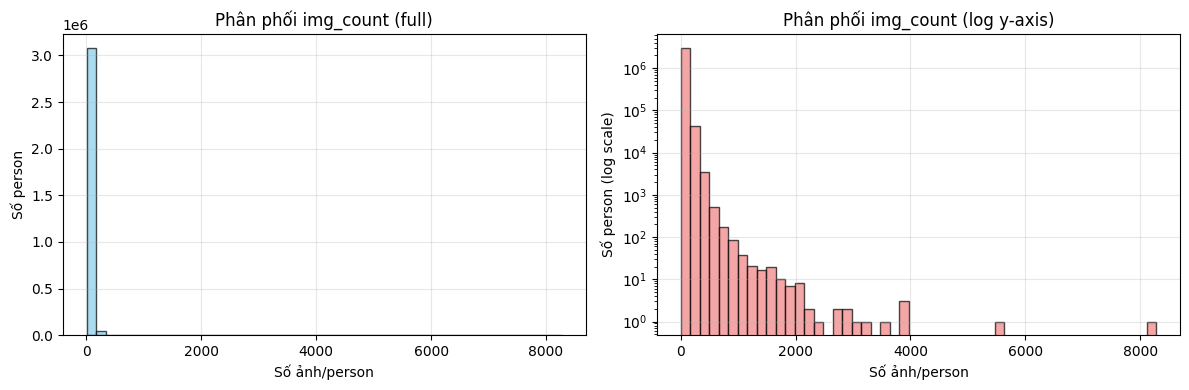


=== 3. TOP 10 BIN CÓ NHIỀU PERSON NHẤT ===
Bin_center | Count
  208     | 3122514
  622     | 1524
 1036     |  128
 1450     |   50
 1864     |   21
 2278     |    7
 2692     |    3
 3105     |    3
 3933     |    3
 3519     |    1


In [15]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Giả sử df_id đã đọc sẵn, mỗi person_id = 1 dòng

print("=== 1. THỐNG KÊ IMG_COUNT ===")
stats = df_id.select([
    pl.col("img_count").min().alias("min"),
    pl.col("img_count").max().alias("max"),
    pl.col("img_count").mean().round(2).alias("mean"),
    pl.col("img_count").median().alias("median"),
    pl.col("img_count").std().round(2).alias("std"),
    pl.len().alias("total_persons"),
])
print(stats)

print("\n=== 2. PHÂN TỔI IMG_COUNT ===")
img_counts = df_id["img_count"].to_numpy()

# Histogram chính
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram đầy đủ
ax1.hist(img_counts, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_xlabel("Số ảnh/person")
ax1.set_ylabel("Số person")
ax1.set_title("Phân phối img_count (full)")
ax1.grid(True, alpha=0.3)

# Histogram log-scale cho tail nặng (nếu có)
ax2.hist(img_counts, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
ax2.set_yscale('log')
ax2.set_xlabel("Số ảnh/person")
ax2.set_ylabel("Số person (log scale)")
ax2.set_title("Phân phối img_count (log y-axis)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Bảng phân phối theo bins (top 10 bins có nhiều person nhất)
print("\n=== 3. TOP 10 BIN CÓ NHIỀU PERSON NHẤT ===")
bins = np.histogram_bin_edges(img_counts, bins=20)
bin_counts, _ = np.histogram(img_counts, bins=bins)
bin_centers = (bins[:-1] + bins[1:]) / 2

top_bins = list(zip(bin_centers[:10], bin_counts[:10]))
print("Bin_center | Count")
for center, count in sorted(top_bins, key=lambda x: x[1], reverse=True)[:10]:
    print(f"{int(center):5d}     | {count:4d}")


/tmp/ipykernel_2400/3784453739.py:26: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  bin_counts = df_binned.group_by("bin_idx").agg(pl.count().alias("count")).sort("bin_idx")


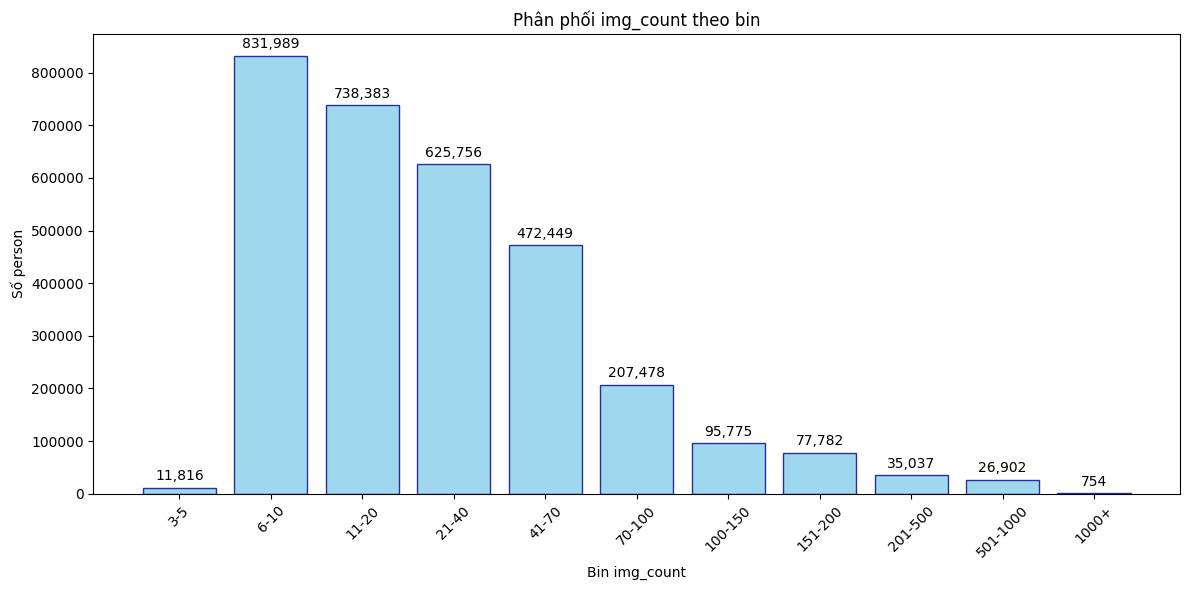

Bin counts: {'3-5': 11816, '6-10': 831989, '11-20': 738383, '21-40': 625756, '41-70': 472449, '70-100': 207478, '100-150': 95775, '151-200': 77782, '201-500': 35037, '501-1000': 26902, '1000+': 754}


In [16]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Định nghĩa bins theo yêu cầu
bins = [3, 6, 11, 21, 41, 71, 101, 151, 201, 501, 1001, float('inf')]
labels = ['3-5', '6-10', '11-20', '21-40', '41-70', '70-100', '100-150', '151-200', '201-500', '501-1000', '1000+']

# Tính count cho từng bin
df_binned = df_id.with_columns(
    pl.when(pl.col("img_count") < 3).then(0)
    .when(pl.col("img_count") < 6).then(1)
    .when(pl.col("img_count") < 11).then(2)
    .when(pl.col("img_count") < 21).then(3)
    .when(pl.col("img_count") < 41).then(4)
    .when(pl.col("img_count") < 71).then(5)
    .when(pl.col("img_count") < 101).then(6)
    .when(pl.col("img_count") < 151).then(7)
    .when(pl.col("img_count") < 201).then(8)
    .when(pl.col("img_count") < 501).then(9)
    .when(pl.col("img_count") < 1001).then(10)
    .otherwise(11)
    .alias("bin_idx")
)

bin_counts = df_binned.group_by("bin_idx").agg(pl.count().alias("count")).sort("bin_idx")
counts = bin_counts["count"].to_list() 
counts = counts[:len(labels)] + [0] * max(0, len(labels) - len(counts))

# Vẽ bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(labels, counts, color='skyblue', edgecolor='navy', alpha=0.8)
plt.title('Phân phối img_count theo bin')
plt.ylabel('Số person')
plt.xlabel('Bin img_count')

# Thêm count label trên bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
             f'{int(count):,}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Bin counts:", dict(zip(labels, counts)))


In [20]:
top_person = (
    df_id
    .select(["person_id", "img_count"])
    .sort("img_count", descending=True)
    .head(1)
)
print(top_person)

shape: (1, 2)
┌───────────┬───────────┐
│ person_id ┆ img_count │
│ ---       ┆ ---       │
│ i64       ┆ i64       │
╞═══════════╪═══════════╡
│ 5641468   ┆ 302228    │
└───────────┴───────────┘


In [21]:
import polars as pl

# Đếm > 100k
num_high = df_id.filter(pl.col("img_count") > 100000).height
print(f"Số person > 100k ảnh: {num_high}")

# Phân phối theo bin
bins = [
    (0, 10000, "0-10k"),
    (10000, 50000, "10k-50k"),
    (50000, 100000, "50k-100k"),
    (100000, float("inf"), ">100k")
]

for low, high, label in bins:
    count = df_id.filter((pl.col("img_count") >= low) & (pl.col("img_count") < high)).height
    print(f"{label}: {count}")


Số person > 100k ảnh: 1
0-10k: 1436761
10k-50k: 0
50k-100k: 0
>100k: 1


In [2]:
webface_map = pl.read_parquet("output_parquet/data_process/offset_map/offset_table_full_webface42m.parquet")
webface_map.head(3)

tar_path,member_name,start_byte,length
str,str,i64,i64
"""cv/projects/face-recognition/webface42m_image_folder/person_0_9999/person_0000013.tar""","""0.jpg""",512,6325
"""cv/projects/face-recognition/webface42m_image_folder/person_0_9999/person_0000013.tar""","""1.jpg""",7680,9140
"""cv/projects/face-recognition/webface42m_image_folder/person_0_9999/person_0000013.tar""","""2.jpg""",17408,5141


In [5]:
len(webface_map)

42473115

In [17]:
import glob
import polars as pl
files = glob.glob("output_parquet/data_process/face_embedding_normalize/clean_data_merge/v1_ivf_real_only_new_id/*.parquet")
test = pl.read_parquet(files)
test.head(3)

person_id,embedding_normalized,aligned_s3_path
i64,list[f64],str
5454341,"[0.018268, 0.069835, … -0.032298]","""cv/processed-datasets/aligned_face_112_112/person_2454000_2454999/person_2454341.tar/cv_crawled-datasets_face-google-search_data_3000_00692.tar_006926943.jpg_face_0.jpg"""
5454341,"[0.030024, 0.059928, … 0.011851]","""cv/processed-datasets/aligned_face_112_112/person_2454000_2454999/person_2454341.tar/cv_crawled-datasets_face-google-search_data_3000_00692.tar_006926945.jpg_face_0.jpg"""
5454341,"[0.032239, 0.06238, … -0.046279]","""cv/processed-datasets/aligned_face_112_112/person_2454000_2454999/person_2454341.tar/cv_crawled-datasets_face-google-search_data_3000_00692.tar_006926944.jpg_face_0.jpg"""


In [18]:
len(test)

19035724

In [19]:
count_rows = test.filter(pl.col("person_id") > 3_000_000).height

# số person_id khác nhau có value > 3_000_000 (mỗi id chỉ tính 1 lần)
count_unique = (
    test
    .filter(pl.col("person_id") > 3_000_000)
    .select(pl.col("person_id").n_unique().alias("n_unique"))
    .item()  # lấy giá trị int từ DataFrame
)

print("Số dòng person_id > 3M:", count_rows)
print("Số person_id unique > 3M:", count_unique)

Số dòng person_id > 3M: 19035724
Số person_id unique > 3M: 1068367


In [20]:
count_rows = test.filter(pl.col("person_id") < 3_000_000).height

# số person_id khác nhau có value > 3_000_000 (mỗi id chỉ tính 1 lần)
count_unique = (
    test
    .filter(pl.col("person_id") > 3_000_000)
    .select(pl.col("person_id").n_unique().alias("n_unique"))
    .item()  # lấy giá trị int từ DataFrame
)

print("Số dòng person_id < 3M:", count_rows)
print("Số person_id unique < 3M:", count_unique)

Số dòng person_id < 3M: 0
Số person_id unique < 3M: 1068367


In [30]:
files_crawl = glob.glob("output_parquet/data_process/face_embedding_normalize/clean_data/v1_ivf_real/*.parquet")
crawl = pl.read_parquet(files_crawl)
crawl.head(3)

person_id,embedding_normalized,aligned_s3_path
i64,list[f64],str
2454341,"[0.018268, 0.069835, … -0.032298]","""cv/processed-datasets/aligned_face_112_112/person_2454000_2454999/person_2454341.tar/cv_crawled-datasets_face-google-search_data_3000_00692.tar_006926943.jpg_face_0.jpg"""
2454341,"[0.030024, 0.059928, … 0.011851]","""cv/processed-datasets/aligned_face_112_112/person_2454000_2454999/person_2454341.tar/cv_crawled-datasets_face-google-search_data_3000_00692.tar_006926945.jpg_face_0.jpg"""
2454341,"[0.032239, 0.06238, … -0.046279]","""cv/processed-datasets/aligned_face_112_112/person_2454000_2454999/person_2454341.tar/cv_crawled-datasets_face-google-search_data_3000_00692.tar_006926944.jpg_face_0.jpg"""


In [31]:
len(crawl)

32365763

In [32]:
dbscan_files = glob.glob("output_parquet/data_process/face_embedding_normalize/dbscan_results/dbscan_v1/*.parquet")
db = pl.read_parquet(dbscan_files)
len(db)

33826262

In [1]:

import polars as pl
pl.Config.set_tbl_width_chars(500)      # Tăng chiều rộng table
pl.Config.set_tbl_cols(20)              # Hiển thị nhiều cột
pl.Config.set_tbl_rows(100)             # Hiển thị nhiều rows
pl.Config.set_fmt_str_lengths(1000)     # Độ dài string max (full S3 path)


polars.config.Config

In [2]:
df_faces = pl.read_parquet("output_parquet/data_process/has_face/all_data.parquet")
len(df_faces)

106787445

In [6]:
import boto3
import tarfile
import io
import polars as pl
import numpy as np
import json
from PIL import Image
from tqdm import tqdm
from multiprocessing import Pool
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import os

# Config (df_faces đã có sẵn)
BUCKET_NAME = "ttnt"
LOCAL_BASE_DIR = "s3_face_samples"
MAX_WORKERS = 8

s3_client = boto3.client("s3", endpoint_url="http://s3-data.cyberspace.vn",
                        aws_access_key_id="ttnt", aws_secret_access_key="<S3_SECRET_KEY>")

# 1. IN-MEMORY STREAMING SAMPLER (df_faces ready)
def get_samples_from_df(df_faces, max_per_bin=9):
    """Iter rows df_faces → stop khi đủ 9/bin"""
    bins = [0,10,15,20,30,50,100,float('inf')]
    labels = ['<10px','10-15px','16-20px','21-30px','31-50px','51-100px','100px+']
    samples = {label: [] for label in labels}
    
    print(f"🔍 Iterating {df_faces.height:,} rows...")
    total_needed = len(labels) * max_per_bin
    
    with tqdm(total=df_faces.height, desc="Sample faces") as pbar:
        for row in df_faces.iter_rows(named=True):
            pbar.update(1)
            
            # Parse bbox → size (first face)
            try:
                bboxes = json.loads(row["bboxs"])
                if bboxes:
                    bbox = bboxes[0][:4]
                    x1,y1,x2,y2 = map(float, bbox)
                    size = np.sqrt((x2-x1)*(y2-y1))
                    
                    # Assign bin
                    for i,(l,r) in enumerate(zip(bins[:-1], bins[1:])):
                        if l <= size < r:
                            label = labels[i]
                            if len(samples[label]) < max_per_bin:
                                samples[label].append({
                                    's3_path': row['s3_path'],
                                    'bbox': bbox,
                                    'size': size
                                })
                                tqdm.write(f"✅ {label}: {size:.0f}px ({len(samples[label])}/{max_per_bin})")
                            break
            except: pass
            
            # STOP condition
            collected = sum(len(s) for s in samples.values())
            if collected >= total_needed: 
                pbar.total = pbar.n  # Stop tqdm
                break
    
    print(f"⏹️ Stopped after {pbar.n:,} rows. Got {collected}/63 faces")
    return samples

# 2. DOWNLOAD + CROP (giữ nguyên)
def download_crop_faces(samples_dict):
    tasks = []
    for label, sample_list in samples_dict.items():
        for s in sample_list:
            tasks.append((s['s3_path'], json.dumps([s['bbox']]), s['size']))
    
    print(f"📥 Download {len(tasks)} faces với {MAX_WORKERS} workers...")
    results = []
    with Pool(MAX_WORKERS) as pool:
        for result in tqdm(pool.imap_unordered(download_crop_face, tasks), 
                          total=len(tasks), desc="Crop faces"):
            if result: 
                results.append(result)
                print(f"💾 Saved {result[0]} ({result[1]:.0f}px)")
    return results

def download_crop_face(args):
    s3_path, bbox_json, size_px = args
    try:
        tar_key, inner_file = s3_path.split(".tar/", 1)
        tar_key += ".tar"
        resp = s3_client.get_object(Bucket=BUCKET_NAME, Key=tar_key)
        with tarfile.open(fileobj=io.BytesIO(resp['Body'].read())) as tar:
            img_data = tar.extractfile(inner_file).read()
            img = Image.open(io.BytesIO(img_data)).convert('RGB')
            bbox = json.loads(bbox_json)[0]
            face_img = img.crop([int(x) for x in bbox])
            
            bin_dir = f"{LOCAL_BASE_DIR}/{int(size_px)}px"
            os.makedirs(bin_dir, exist_ok=True)
            save_path = os.path.join(bin_dir, f"{int(size_px)}px_{os.path.basename(inner_file)}.jpg")
            face_img.save(save_path, quality=95)
            return save_path, size_px
    except Exception as e:
        return None

# 3. PLOT 3x3 GRID/BIN
def plot_face_bins(results):
    sizes = sorted(set(int(s) for _,s in results))
    n_bins = len(sizes)
    n_rows = (n_bins + 2) // 3
    
    fig = make_subplots(rows=n_rows, cols=3,
                       subplot_titles=[f"{size}px ({len([p for p,s in results if int(s)==size])} imgs)"
                                     for size in sizes],
                       specs=[[{'type': 'image'}]*3 for _ in range(n_rows)],
                       vertical_spacing=0.08)
    
    row,col = 1,1
    for size in sizes:
        bin_paths = [p for p,s in results if int(s)==size]
        for i, path in enumerate(bin_paths[:9]):
            img = Image.open(path)
            fig.add_trace(go.Image(z=np.array(img)), row=row, col=col)
            col += 1
            if col > 3:
                col,row = 1, row+1
        
        col,row = 1, row+1 if col>1 else row
    
    fig.update_layout(height=400*n_rows, width=1200,
                     title="Face Size Distribution: 9 Samples Each Bin", 
                     showlegend=False)
    fig.show()

# CHẠY NGAY:
if __name__ == "__main__":
    samples = get_samples_from_df(df_faces)  # df_faces ready
    cropped_faces = download_crop_faces(samples)
    plot_face_bins(cropped_faces)
    print(f"✅ Hoàn thành! Files in {LOCAL_BASE_DIR}")


🔍 Iterating 106,787,445 rows...


✅ 100px+: 140px (1/9)
✅ 100px+: 204px (2/9)
✅ 100px+: 710px (3/9)
✅ 51-100px: 55px (1/9)
✅ 21-30px: 27px (1/9)
✅ 51-100px: 100px (2/9)
✅ 100px+: 129px (4/9)
✅ 100px+: 219px (5/9)
✅ 51-100px: 91px (3/9)
✅ 31-50px: 47px (1/9)
✅ 51-100px: 92px (4/9)
✅ 100px+: 212px (6/9)
✅ 51-100px: 86px (5/9)
✅ 51-100px: 92px (6/9)
✅ 100px+: 132px (7/9)
✅ 100px+: 171px (8/9)
✅ 100px+: 130px (9/9)
✅ 51-100px: 82px (7/9)
✅ 31-50px: 40px (2/9)
✅ 31-50px: 42px (3/9)
✅ 31-50px: 37px (4/9)
✅ 51-100px: 65px (8/9)
✅ 51-100px: 65px (9/9)
✅ 31-50px: 32px (5/9)
✅ 21-30px: 22px (2/9)
✅ 16-20px: 20px (1/9)
✅ 21-30px: 26px (3/9)
✅ 31-50px: 50px (6/9)
✅ 31-50px: 42px (7/9)
✅ 31-50px: 39px (8/9)
✅ 31-50px: 49px (9/9)
✅ 21-30px: 26px (4/9)
✅ 21-30px: 20px (5/9)
✅ 21-30px: 24px (6/9)
✅ 21-30px: 27px (7/9)
✅ 21-30px: 28px (8/9)
✅ 21-30px: 28px (9/9)
✅ 10-15px: 14px (1/9)
✅ 16-20px: 15px (2/9)
✅ 16-20px: 16px (3/9)
✅ <10px: 10px (1/9)
✅ 10-15px: 14px (2/9)
✅ 10-15px: 15px (3/9)
✅ 16-20px: 15px (4/9)
✅ 10-15px: 10px (4/9)
✅ 

Sample faces:   0%|                                                                                                                   | 472/106787445 [00:00<11:24:03, 2601.79it/s]

✅ 16-20px: 18px (7/9)
✅ 10-15px: 13px (6/9)
✅ 10-15px: 14px (7/9)


Sample faces: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 984/984 [00:00<00:00, 3551.05it/s]


...

Crop faces:  98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 62/63 [02:50<00:02,  2.07s/it]

💾 Saved s3_face_samples/170px/170px_000120013.jpg.jpg (171px)


Crop faces: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [02:51<00:00,  2.73s/it]

💾 Saved s3_face_samples/129px/129px_000120033.jpg.jpg (130px)


ValueError: Vertical spacing cannot be greater than (1 / (rows - 1)) = 0.076923.
The resulting plot would have 14 rows (rows=14).